# Import packages needed for running code

In [92]:
import numpy as np
import itertools as it
from environment import Environment
from numpy.typing import NDArray

# Initiate environment

In [93]:
env = Environment()
env.sim_length = 1

# Define state space, probabilities, action space and reward space

In [94]:
def get_variables(env):
    '''Initiate all variables.

    :param env: Class Environment. Contains the environment.
    :return: state space, number of states, number of actions
        reward matrix and policy matrix.
    '''
    BSPlvl = env.base_stock
    S = np.arange(BSPlvl + 1)
    SS = np.array(list(it.product(S, repeat = env.M)))

    valid = SS.sum(axis=1) <= BSPlvl
    SS = SS[valid]
    nS = len(SS)

    nA = env.discount_levels

    RR = np.zeros([nA, nS])
    PP = np.zeros([nA, nS, nS]) # Changed nS1 to nS for the third dimension
    return SS, nS, nA, RR, PP

In [95]:
SS, nS, nA, RR, PP = get_variables(env)

# Check the number of states

In [96]:
def check_states(PP:NDArray, actionStates:bool = False) -> None:
    '''Check number of possible states under the constraints of the environment.

    :param PP: 3D array of shape (nA,nS,nS), contains the probabilities of reaching
        the next state S' given current state S and current action A.
    :param actionStates: bool, indicates whether only the number of
        possible states should be printed, or also the number of possible
        states while performing action A. The latter is only valid if the
        probability matrix PP is filled.
    :return: None
    '''

    print(f"Total number of states: {PP.shape[1]}")
    for i in range(PP.shape[0]):
        count = 0
        for j in range(PP.shape[1]):
            if PP[i, j, :].sum() == 1.0:
                count += 1
        if actionStates:
            print(f'Action {i} has {count} possible states.')


In [97]:
# check number of possible states
check_states(PP, actionStates = False)

Total number of states: 1287


# Compute reward and probability matrix
<ol>
  <li>Action: a discount on the oldest product.</li>
  <li>Reward: LEFO + FEFO - order costs</li>
  <li>State: combination of number of items per product age per day</li>
  <li>Probability: poisson model distribution around mu = 3</li>
</ol>





In [98]:
def get_matrices(env, SS, PP, RR):
    '''

     :param env: Class environment. Contains the environment.
    :param SS: np.array of shape (nS,M). Contains all states.
    :param PP: np.array of shape (nA,nS,nS). Contains probabilites for
        next state space given a current state and action.
    :param RR: np.array of shape (nA,nS). Contains the rewards for each action space.
    :return: rewards matrix and probability matrix.
    '''

    for ida, a in enumerate(range(env.discount_levels)): # action: discount
        env.reset()
        for ids, s in enumerate(SS):
            PP, tot_profit = env.get_probability_matrix(SS,PP,s,ida,ids,a)
            RR[ida, ids] = tot_profit
    return PP, RR

In [99]:
PP, RR = get_matrices(env,SS,PP,RR)

# Use Iterative Policy Evaluation with Policy Improvement.

In [100]:
def policy_iteration_and_evaluation(nA:int, nS:int, SS:NDArray, RR:NDArray, PP:NDArray, verbose:bool = False):
    '''Perform policy iteration and iterative policy evaluation.

    :param nA: int. Number of possible actions.
    :param nS: int. Number of possible states.
    :param RR: np.array of shape (nA,nS). Contains the rewards for action spaces.
    :param PP: np.array of shape (nA, nS, nS). Contains probabilites of the next state
        given the current action and state.
    :param verbose: bool. Whether to track model progress while running. Default = False.
    :return: best policy, np.array of shape (nS).
    '''

    pi = np.random.choice(np.arange(nA), size = nS)
    V = np.zeros(nS)
    gamma = 0.999
    PolicyNotStable = True
    niterPI = 0

    while PolicyNotStable:
        V, niterIPE = iterative_policy_evalutation(SS, pi, nA, V, RR, PP, gamma)
        PolicyNotStable, pi = policy_improvement(pi,V,RR,PP,nS,nA,SS)
        niterPI += 1
        if verbose:
            print(f'niterPI: {niterPI}\tniterIPE: {niterIPE}')

    return pi

In [101]:
def iterative_policy_evalutation(SS:NDArray, pi:NDArray, nA:int, V:NDArray, RR:NDArray, PP:NDArray, gamma:float = 0.9):
    '''Perform iterative policy evaluation.

    :param SS: np.array of shape (nS,M). Contains all possible states.
    :param pi: np.array of shape (nS). Contains a policy.
    :param nA: int. Number of possible actions.
    :param V: np.array of shape (nS). Contains the expected reward for any state.
    :param RR: np.array of shape (nA,nS). Contains the rewards for action spaces.
    :param PP: np.array of shape (nA, nS, nS). Contains probabilites of the next state
        given the current action and state.
    :param gamma: float. Discount in the Bellman equation. Default = 0.9.
    :return: Updated state value vector under the given policy and optionally
        the number of times the algorithm was run.
    '''

    niterIPE = 0
    theta = 0.0001 * (1 - gamma) / (2 * gamma)
    span = 1 + theta
    while span > theta:
        V_prev = V.copy()
        niterIPE += 1
        for ids, s in enumerate(SS):
            a = pi[ids]
            ida = np.where(np.arange(nA) == a)[0][0]  # look up the action index associated with action a
            V[ids] = RR[ida, ids] + gamma * PP[ida, ids, :] @ V_prev

        Diff = V - V_prev
        span = max(Diff) - min(Diff)
        niterIPE += 1
    return V, niterIPE


In [102]:
def policy_improvement(pi:NDArray, V:NDArray, RR:NDArray, PP:NDArray, nS:int, nA:int, SS:NDArray, gamma:float = 0.9):
    '''Perform policy improvement.

    :param pi: np.array of shape (nS). Contains a policy.
    :param V: np.array of shape (nS). Contains the expected state values for any state.
    :param RR: np.array of shape (nA,nS). Contains the rewards for action spaces.
    :param PP: np.array of shape (nA, nS, nS). Contains probabilites of the next state
        given the current action and state.
    :param nS: int. Number of states.
    :param nA: int. Number of actions.
    :param SS: np.array of shape (nS, nS). Contains all states.
    :param gamma: float. Discount according to the Bellman equation. Default = 0.9.
    :return: bool, whether the best policy was found. np.array of shape (nS) that
        contains the best policy.
    '''

    q = np.zeros([nA, nS])

    # POLICY IMPROVEMENT
    pi_prev = pi.copy()
    PolicyNotStable = False
    for ids, s in enumerate(SS):
        qbest = - np.inf
        for ida, a in enumerate(np.arange(nA)):
            q[ida, ids] = RR[ida, ids] + gamma * PP[ida, ids, :] @ V
            if q[ida, ids] > qbest:
                pi[ids] = a
                qbest = q[ida, ids]
        if pi[ids] != pi_prev[ids]:
            PolicyNotStable = True
    return PolicyNotStable, pi

In [103]:
pi = policy_iteration_and_evaluation(nA,nS,SS,RR,PP)

# Look into the contents of the final policy

In [104]:
def print_policy_contents(pi:NDArray) -> None:
    '''Print the number of times an action is chosen in pi.

    :param pi: np.array of shape (nS). Contains the action to take
        for a given state.
    :return: None
    '''
    val_d = {}
    for i in pi:
        if i in val_d:
            val_d[i] += 1
        else:
            val_d[i] = 1

    for key in sorted(val_d.keys()):
        print(f'Action {key} is chosen {val_d[key]} times')

In [105]:
print_policy_contents(pi)

Action 0 is chosen 548 times
Action 1 is chosen 51 times
Action 2 is chosen 115 times
Action 3 is chosen 189 times
Action 4 is chosen 190 times
Action 5 is chosen 119 times
Action 6 is chosen 59 times
Action 7 is chosen 13 times
Action 8 is chosen 3 times


# Run the policy on the model

In [106]:
def run_dp_model(pi:NDArray):
    '''Run the best policy in the environment.

    :param pi: np.array of shape (nS). Contains a policy (the best).
    :return: mean profit, waste and fill rate, all float.
    '''
    env = Environment()

    done = False
    while not done:
        pi_a_idx = np.where((SS == env.inventory_matrix[env.t]).all(axis = 1))[0][0].item()
        action = pi[pi_a_idx]
        _, _, done = env.step(action)

    profit = env.get_statistics()['profit']
    waste = env.get_statistics()['waste']
    fill_rate = env.get_statistics()['fill_rate']
    return profit, waste, fill_rate

In [107]:
profit, waste, fill_rate = run_dp_model(pi)
print(profit)
print(waste)
print(fill_rate)

174.29931506849314
0.05517623524329198
0.920237093410413


# Value iteration

In [25]:
def value_iteration(nA:int, nS:int, gamma:float = 0.9, K:int = 50, Theta:int = 1, verbose = False):
    '''Perform value iteration as dynamic programming

    :param nA: int. Number of actions.
    :param nS: int. Number of states.
    :param gamma: float. The discount value in the Bellman equation. Default = 0.9.
    :param K: int. maximum number Value Iteration has to be performed. Default = 50.
    :param Theta: int. Limits the model to perform Value Iteration when
        the difference between new and old state value vectors is nihil. Default = 1.
    :param verbose: bool. Whether algorithm progress should be visible. Default = False.
    :return: best policy of type np.array with shape (nS)
    '''

    pi = np.random.choice(np.arange(nA), nS)  # fixed policy
    V = np.zeros(nS)
    niterVI = 0
    stop = False
    k = 0

    while not stop:
        if verbose:
            print(f'niterVI: {niterVI}')
        k += 1
        Delta = 0

        for ids, s in enumerate(SS):
            vs = V[ids]
            Vbest = -99999

            for ida, a in enumerate(np.arange(nA)):
                Vtry = RR[ida,ids] + gamma * PP[ida, ids, :] @ V
                if Vtry > Vbest:
                    Vbest = Vtry
                    pi[ids] = a
            V[ids] = Vbest
            if Delta < abs(V[ids] - vs):
                Delta = abs(V[ids] - vs)
        if (k == K) or (Delta < Theta):
            stop = True
        niterVI += 1

    return pi

In [33]:
pi = value_iteration(nA, nS)
print_policy_contents(pi)

Action 0 is chosen 543 times
Action 1 is chosen 45 times
Action 2 is chosen 104 times
Action 3 is chosen 172 times
Action 4 is chosen 187 times
Action 5 is chosen 125 times
Action 6 is chosen 75 times
Action 7 is chosen 21 times
Action 8 is chosen 14 times
Action 10 is chosen 1 times


In [53]:
profit, waste, fill_rate = run_model(pi)
print(profit)
print(waste)
print(fill_rate)

174.29931506849314
0.05517623524329198
0.920237093410413


# Baseline to compare model with



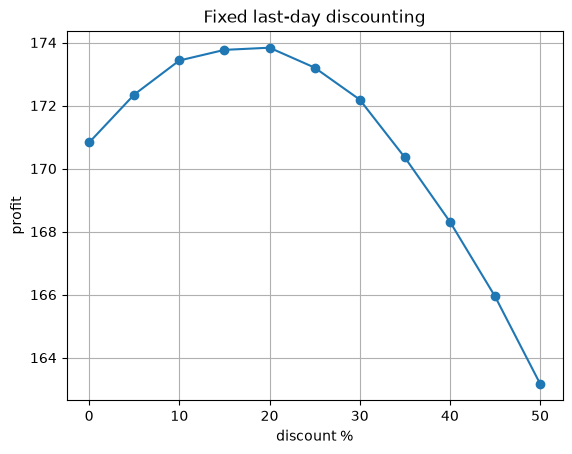

In [68]:
env = Environment()
profits = []
for action in range(env.discount_levels):
    env.reset()
    done = False
    while not done:
        _, _, done = env.step(action)
    profits.append(env.get_statistics()['profit'])

env.plot_env_results(profits)

# Functions to evaluate model

In [110]:
def run_IPE_and_PI(env):
    '''Run Iterative Policy Evaluation and Policy Improvement.

    :param env: Class Environment. Contains the environment.
    :return: policy, profit, waste, fill rate
    '''

    SS, nS, nA, RR, PP = get_variables(env)
    PP, RR = get_matrices(env,SS,PP,RR)
    pi = policy_iteration_and_evaluation(nA,nS,SS,RR,PP)
    profit, waste, fill_rate = run_dp_model(pi)
    return pi, profit, waste, fill_rate

In [111]:
print(run_IPE_and_PI(env))

(array([0, 0, 0, ..., 0, 0, 0], shape=(1287,)), np.float64(174.29931506849314), np.float64(0.05517623524329198), np.float64(0.920237093410413))


In [112]:
def run_VI(env):
    '''Run Value Iteration.

    :param env: Class Environment. Contains the environment.
    :return: policy, profit, waste, fill rate
    '''

    SS, nS, nA, RR, PP = get_variables(env)
    PP, RR = get_matrices(env,SS,PP,RR)
    pi = value_iteration(nA,nS)
    profit, waste, fill_rate = run_dp_model(pi)
    return pi, profit, waste, fill_rate

In [113]:
print(run_VI(env))

(array([0, 0, 0, ..., 0, 0, 0], shape=(1287,)), np.float64(174.42020547945205), np.float64(0.05419450631031923), np.float64(0.9206395667922871))


In [70]:
I, IL, BSPlvl, Order, D, DF, DL, DeltaF, DeltaL, SALES, PRF, LS, WST, Profit = initialize()

rd.seed(1)
np.random.seed(1)
I[:] = np.zeros([T + 1, M], dtype=int)
IL[:] = np.zeros([T, M], dtype=int)
BSPlvl[:] = np.zeros(T, dtype=int)
Order[:] = np.zeros(T, dtype=int)
D[:] = np.zeros(T, dtype=int)
DF[:] = np.zeros(T, dtype=int)
DL[:] = np.zeros(T, dtype=int)
DeltaF[:] = np.zeros([T, M], dtype=int)
DeltaL[:] = np.zeros([T, M], dtype=int)
SALES[:] = np.zeros(T, dtype=int)
PRF[:] = np.zeros(T)
LS[:] = np.zeros(T, dtype=int)
WST[:] = np.zeros(T, dtype=int)

# SIMULATE INVENTORY DYANMICS OVER ALL PERIODS
for t in range(T):

    # predict demand and set BSP level
    BSPlvl[t] = round(2 * mu + z * sqrt(2) * mu)

    # set discount
    pi_a_idx = np.where((SS == I[t]).all(axis = 1))[0][0].item()
    a = 0.05 * pi[pi_a_idx]

    # set order quantity:
    Order[t] = max(0, BSPlvl[t] - I[t].sum())

    # set demand:
    D[t] = min(Dmx, np.random.poisson(mu))

    # split demand
    DF_frac = min(I[t, M - 1], a * D[t])
    DF_int = int(DF_frac)
    DF[t] = DF_int
    if DF_frac != DF_int:  # stochastic rounding
        Frac = DF_frac - DF_int
        u = rd.random()
        if u < Frac:
            DF[t] = DF_int + 1
    DL[t] = D[t] - DF[t]

    # pick FEFO demand:
    DeltaF[t, M - 1] = DF[t]  # only oldest are discounted (<= max I[t,M-1])

    # available for LEFO customers/adjust stock levels:
    IL[t] = I[t] - DeltaF[t]

    # pick LEFO demand:
    DeltaL[t, 0] = min(DL[t], IL[t, 0])  # youngest first
    for i in range(1, M):
        DeltaL[t, i] = min(DL[t] - DeltaL[t, 0:i].sum(), IL[t, i])

    # adjust stock levels:
    I[t + 1, :] = IL[t] - DeltaL[t]
    WST[t] = I[t + 1, M - 1]
    I[t + 1, :] = np.roll(I[t + 1], 1)
    I[t + 1, 0] = Order[t]  # as lead time is one period

    # more stats:
    LS[t] = max(0, D[t] - I[t].sum())
    SALES[t] = DeltaF[t].sum() + DeltaL[t].sum()
    PRF[t] = r * DeltaL[t].sum() + r * (1 - a) * DeltaF[t].sum() - c * Order[t]

WasteRel = WST[Tw:T].mean() / Order[Tw:T].mean()
Fillrate = 1 - LS[Tw:T].mean() / D[Tw:T].mean()
Profit = PRF[Tw:T].mean()
print(f"Profit = {Profit:.3f}, Waste = {WasteRel * 100:.1f} %, Fillrate = {Fillrate * 100:.1f} %")

Profit = 161.330, Waste = 8.6 %, Fillrate = 95.2 %
